In [1]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
# matplotlib.use('Agg')
import datetime

%matplotlib inline
from finrl.meta.preprocessor.yahoodownloader import YahooDownloader
from finrl.meta.preprocessor.preprocessors import FeatureEngineer, data_split
from finrl.meta.env_stock_trading.env_stocktrading import StockTradingEnv
from finrl.agents.stablebaselines3.models import DRLAgent
from stable_baselines3.common.logger import configure
from finrl.meta.data_processor import DataProcessor

from finrl.plot import backtest_stats, backtest_plot, get_daily_return, get_baseline
from pprint import pprint

import sys
sys.path.append("../FinRL")

import itertools

C:\Users\silve\anaconda3\envs\CM3070-FP\lib\site-packages\pyfolio\pos.py:25: UserWarning: Module "zipline.assets" not found; multipliers will not be applied to position notionals.
  warnings.warn(


warning above is not an issue since we are working with stocks, not futures so the multiplier is 1 by default.

In [2]:
from finrl import config
from finrl import config_tickers
import os
from finrl.main import check_and_make_directories
from finrl.config import (
    DATA_SAVE_DIR,
    TRAINED_MODEL_DIR,
    TENSORBOARD_LOG_DIR,
    RESULTS_DIR,
    INDICATORS,
    TRAIN_START_DATE,
    TRAIN_END_DATE,
    TEST_START_DATE,
    TEST_END_DATE,
    TRADE_START_DATE,
    TRADE_END_DATE,
)
check_and_make_directories([DATA_SAVE_DIR, TRAINED_MODEL_DIR, TENSORBOARD_LOG_DIR, RESULTS_DIR])

In [3]:
# from config.py, TRAIN_START_DATE is a string
TRAIN_START_DATE

'2014-01-06'

In [4]:
# from config.py, TRAIN_END_DATE is a string
TRAIN_END_DATE

'2020-07-31'

In [5]:
TODAY = datetime.datetime.today().strftime('%Y-%m-%d')

In [6]:
TRAIN_START_DATE = '2008-01-01'
TRAIN_END_DATE = '2023-01-01'
TRADE_START_DATE = '2023-01-01'
TRADE_END_DATE = TODAY

In [44]:
ticker_list = ['AAPL', 'AMGN', 'AMZN', 'AXP', 'BA', 'CAT', 'CRM', 'CSCO', 'CVX', 'DIS', 'GS', 'HD', 'HON', 'IBM', 'JNJ', 'JPM', 'KO', 'MCD', 'MMM', 'MRK', 'MSFT', 'NKE', 'NVDA', 'PG', 'SWH', 'TRV', 'UNH', 'V', 'VZ', 'WMT']

In [45]:
df = YahooDownloader(start_date = TRAIN_START_DATE,
                     end_date = TRADE_END_DATE,
                     ticker_list = ticker_list).fetch_data()

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%********

Shape of DataFrame:  (129504, 8)


In [46]:
df

Price,date,close,high,low,open,volume,tic,day
0,2008-01-02,5.855757,6.018651,5.786934,5.988897,1079178800,AAPL,2
1,2008-01-02,32.223801,32.528061,31.988691,32.223801,7934400,AMGN,2
2,2008-01-02,4.812500,4.871500,4.735000,4.767500,277174000,AMZN,2
3,2008-01-02,38.898701,39.874216,38.708170,39.698928,8053700,AXP,2
4,2008-01-02,63.481628,64.375731,63.027244,64.177857,4303000,BA,2
...,...,...,...,...,...,...,...,...
129499,2025-06-06,273.690002,275.579987,272.079987,273.309998,695500,TRV,4
129500,2025-06-06,303.220001,304.390015,297.149994,297.230011,12570500,UNH,4
129501,2025-06-06,370.220001,371.000000,367.549988,369.010010,5007900,V,4
129502,2025-06-06,43.799999,43.919998,43.380001,43.400002,10133100,VZ,4


In [10]:
df.columns

Index(['date', 'close', 'high', 'low', 'open', 'volume', 'tic', 'day'], dtype='object', name='Price')

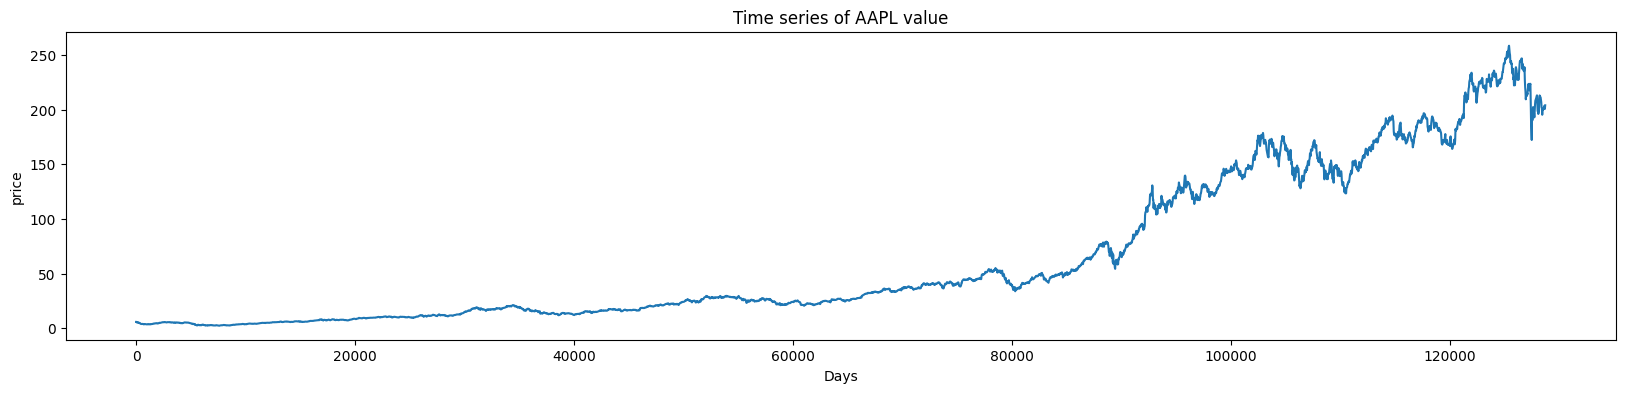

In [11]:
%matplotlib inline
# Create plot
fig, ax = plt.subplots(figsize=(20, 4))
ax.plot(df[df['tic'] == 'AAPL']['close'])
plt.title("Time series of AAPL value")
plt.xlabel("Days")
plt.ylabel("price")
plt.show()

In [47]:
fe = FeatureEngineer(
                    use_technical_indicator=True,
                    tech_indicator_list = INDICATORS,
                    use_vix=True,
                    use_turbulence=True,
                    user_defined_feature = False)

processed = fe.preprocess_data(df)

[*********************100%***********************]  1 of 1 completed

Successfully added technical indicators
Shape of DataFrame:  (4385, 8)
Successfully added vix


Successfully added turbulence index


In [48]:
list_ticker = processed["tic"].unique().tolist()
list_date = list(pd.date_range(processed['date'].min(),processed['date'].max()).astype(str))
combination = list(itertools.product(list_date,list_ticker))

processed_full = pd.DataFrame(combination,columns=["date","tic"]).merge(processed,on=["date","tic"],how="left")
processed_full = processed_full[processed_full['date'].isin(processed['date'])]
processed_full = processed_full.sort_values(['date','tic'])

processed_full = processed_full.fillna(0)

In [49]:
processed_full.sort_values(['date','tic'],ignore_index=True).head(20)

,date,tic,close,high,low,open,volume,day,macd,boll_ub,boll_lb,rsi_30,cci_30,dx_30,close_30_sma,close_60_sma,vix,turbulence
0,2008-01-02,AAPL,5.855757,6.018651,5.786934,5.988897,1.079179e+09,2.0,0.0,5.860936,5.853283,100.0,-66.666667,100.0,5.855757,5.855757,23.17,0.0
1,2008-01-02,AMGN,32.223801,32.528061,31.988691,32.223801,7.934400e+06,2.0,0.0,5.860936,5.853283,100.0,-66.666667,100.0,32.223801,32.223801,23.17,0.0
2,2008-01-02,AMZN,4.812500,4.871500,4.735000,4.767500,2.771740e+08,2.0,0.0,5.860936,5.853283,100.0,-66.666667,100.0,4.812500,4.812500,23.17,0.0
3,2008-01-02,AXP,38.898701,39.874216,38.708170,39.698928,8.053700e+06,2.0,0.0,5.860936,5.853283,100.0,-66.666667,100.0,38.898701,38.898701,23.17,0.0
4,2008-01-02,BA,63.481628,64.375731,63.027244,64.177857,4.303000e+06,2.0,0.0,5.860936,5.853283,100.0,-66.666667,100.0,63.481628,63.481628,23.17,0.0
5,2008-01-02,CAT,44.507313,45.792814,44.141831,45.723498,6.337800e+06,2.0,0.0,5.860936,5.853283,100.0,-66.666667,100.0,44.507313,44.507313,23.17,0.0
6,2008-01-02,CRM,14.962784,15.774468,14.861013,15.650357,4.980000e+06,2.0,0.0,5.860936,5.853283,100.0,-66.666667,100.0,14.962784,14.962784,23.17,0.0
7,2008-01-02,CSCO,17.473333,17.973699,17.256068,17.776186,6.433890e+07,2.0,0.0,5.860936,5.853283,100.0,-66.666667,100.0,17.473333,17.473333,23.17,0.0
8,2008-01-02,CVX,47.075184,47.694728,46.697414,47.327031,9.058000e+06,2.0,0.0,5.860936,5.853283,100.0,-66.666667,100.0,47.075184,47.075184,23.17,0.0
9,2008-01-02,DIS,26.682873,27.344917,26.557169,27.085127,9.269900e+06,2.0,0.0,5.860936,5.853283,100.0,-66.666667,100.0,26.682873,26.682873,23.17,0.0


In [15]:
train = data_split(processed_full, TRAIN_START_DATE,TRAIN_END_DATE)
trade = data_split(processed_full, TRADE_START_DATE,TRADE_END_DATE)
print(len(train))
print(len(trade))

105756
17024


In [16]:
train.tail()

,date,tic,close,high,low,open,volume,day,macd,boll_ub,boll_lb,rsi_30,cci_30,dx_30,close_30_sma,close_60_sma,vix,turbulence
3776,2022-12-30,TRV,179.279114,181.086343,178.284651,180.722980,608200.0,4.0,1.477335,182.798014,174.923962,56.428717,46.056427,6.869163,178.535774,172.357864,21.67,5.181147
3776,2022-12-30,UNH,512.076233,512.385313,506.918608,511.902386,1849600.0,4.0,-0.693239,529.770321,500.275779,50.390149,-30.048615,1.719502,513.389752,510.954848,21.67,5.181147
3776,2022-12-30,VZ,33.277485,33.522418,32.998763,33.201470,44007200.0,4.0,0.260706,33.362614,30.590963,53.943990,130.323583,28.954356,32.195260,31.748041,21.67,5.181147
3776,2022-12-30,WBA,32.217491,32.234739,31.881174,32.114010,5406200.0,4.0,-0.398673,36.474666,31.806406,46.462096,-170.508025,26.033663,34.556766,32.465042,21.67,5.181147
3776,2022-12-30,WMT,45.765247,45.829804,45.448937,45.691013,11505900.0,4.0,-0.347775,49.112887,44.951407,48.559204,-121.727644,25.537374,47.634376,46.007581,21.67,5.181147


In [17]:
trade.head()

,date,tic,close,high,low,open,volume,day,macd,boll_ub,boll_lb,rsi_30,cci_30,dx_30,close_30_sma,close_60_sma,vix,turbulence
0,2023-01-03,AAPL,123.470619,129.226060,122.582127,128.613993,112117500.0,1.0,-4.648599,147.860264,121.091840,39.011488,-130.963475,35.956397,138.293934,140.567288,22.9,49.721079
0,2023-01-03,AMGN,241.367722,242.244092,238.803219,240.648186,2594800.0,1.0,-3.707346,265.600955,233.467111,46.085263,-104.624905,29.740878,254.056502,248.620166,22.9,49.721079
0,2023-01-03,AXP,142.451492,145.675824,141.105601,144.794698,2762200.0,1.0,-1.468839,154.283570,136.367062,47.808121,-62.042637,4.879769,146.752542,143.748914,22.9,49.721079
0,2023-01-03,BA,195.389999,197.179993,192.399994,192.949997,8624600.0,1.0,5.326285,196.702727,176.154272,62.905353,141.206999,44.456630,182.859667,166.269167,22.9,49.721079
0,2023-01-03,CAT,228.451080,230.172485,225.888075,230.172485,2651900.0,1.0,3.482379,233.864476,215.825906,59.678872,81.552171,11.393556,224.782548,210.932085,22.9,49.721079


In [18]:
trade.tail()

,date,tic,close,high,low,open,volume,day,macd,boll_ub,boll_lb,rsi_30,cci_30,dx_30,close_30_sma,close_60_sma,vix,turbulence
607,2025-06-05,TRV,271.019989,273.049988,269.500000,271.609985,773000.0,3.0,3.007129,279.105348,264.606651,54.988878,35.577742,1.918194,269.325999,262.397667,18.48,13.494787
607,2025-06-05,UNH,295.839996,302.420013,294.109985,300.380005,13529000.0,3.0,-31.948072,375.221661,250.641346,31.593168,-63.403455,37.369802,344.439003,431.241499,18.48,13.494787
607,2025-06-05,VZ,43.299999,43.410000,43.029999,43.349998,12095900.0,3.0,0.056471,44.508041,42.472960,50.744104,-21.761812,13.911876,43.418334,43.369835,18.48,13.494787
607,2025-06-05,WBA,11.250000,11.280000,11.240000,11.250000,9437500.0,3.0,0.050774,11.362036,11.101964,53.877684,67.497601,28.751298,11.150000,11.080333,18.48,13.494787
607,2025-06-05,WMT,97.959999,99.589996,97.610001,99.300003,15817100.0,3.0,1.110664,99.954823,95.073677,54.668199,69.154617,8.103580,97.341661,92.624662,18.48,13.494787


In [19]:
INDICATORS

['macd',
 'boll_ub',
 'boll_lb',
 'rsi_30',
 'cci_30',
 'dx_30',
 'close_30_sma',
 'close_60_sma']

In [60]:
import reservoirpy as rpy
from reservoirpy.nodes import Reservoir, Ridge
from reservoirpy.observables import mse, nrmse, rmse
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import time

In [61]:
def normalize_data(train, test):
    data_min = min(train.min(), test.min())
    data_max = max(train.max(), test.max())
    return (train - data_min)/ (data_max - data_min), (test - data_min)/ (data_max - data_min), data_min, data_max

def calculate_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse_val = np.sqrt(mean_squared_error(y_true, y_pred))
    mask = y_true != 0
    mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100
    mse_score = mse(y_true, y_pred)
    rmse_score = rmse_val  # Change the variable name here
    nmrse_mean = nrmse(y_true, y_pred, norm_value=y_true.mean())
    nmrse_maxmin = nrmse(y_true, y_pred, norm_value=y_true.max() - y_true.min())
    r2 = r2_score(y_true, y_pred)
    return mae, rmse_score, mape, mse_score, rmse_score, nmrse_mean, nmrse_maxmin, r2

In [62]:
def filter_data(dataframe, ticker, column):
    return dataframe[dataframe['tic'] == ticker][column]

In [182]:
def create_lagged_dataset_from_full(x, x1, n_lags, horizon):
    full = np.concatenate([x, x1])  # Combine to maintain continuity

    X_all, y_all = [], []
    for i in range(len(full) - n_lags - horizon + 1):
        X_all.append(full[i:i + n_lags])
        y_all.append(full[i + n_lags + horizon - 1])

    X_all = np.array(X_all)
    y_all = np.array(y_all).reshape(-1, 1)

    # Determine split index: all points where inputs are from `x` only
    train_cutoff = len(x) - n_lags - horizon + 1

    X_train, y_train = X_all[:train_cutoff], y_all[:train_cutoff]
    X_test, y_test = X_all[train_cutoff:], y_all[train_cutoff:]

    return X_train, y_train, X_test, y_test

In [237]:
def train_rc_model(train, test, ticker, column, horizon):
    
    train = filter_data(train, ticker, column)
    test = filter_data(test, ticker, column)
    
    Dat = np.array(train)
    dat = np.array(test)

    # Set constants
    SEED = 42
    VERBOSE = True
    units = 10000
    z = horizon
    if __name__ == "__main__":
        rpy.set_seed(SEED)
        rpy.verbosity(0)

        if VERBOSE:
            print("Train", Dat.shape)
            print("max:", Dat.max(), "min:", Dat.min())
            print("mean:", Dat.mean(), "std:", Dat.std())

            print("Test", dat.shape)
            print("max:", dat.max(), "min:", dat.min())
            print("mean:", dat.mean(), "std:", dat.std())

        x, x1, minima, maxima = normalize_data(Dat, dat)

        n_lags = z

        X, y, X_test, y_test = create_lagged_dataset_from_full(x, x1, n_lags, z)
        
        #y = np.concatenate((x[z:], x1[:z])).reshape(-1, 1)
        #X_test = x1[:len(X1)-z].reshape(-1, 1)
        #y_test = x1[z:].reshape(-1, 1)
        #X = x.reshape(-1, 1)

        print(X.shape)
        print(y.shape)
        print(X_test.shape)
        print(y_test.shape)

        # Reservoir parameters
        units = 50
        leak_rate = 0.5
        rho = 1.0
        input_scaling = 1.0
        rc_connectivity = 0.15
        input_connectivity = 0.2
        fb_connectivity = 1.1
        regularization_coef = 1e-6
        warmup = 200
        feedback = False

        rng = np.random.default_rng(SEED)
        W = rng.random((units, units)) - 0.5
        input_bias = True  # Set to True or False depending on your choice
        Win = rng.random((units, 1 + int(input_bias))) - 0.5
        Wfb = rng.random((units, 1)) - 0.5

        mask = rng.random((units, units))
        W[mask > rc_connectivity] = 0

        mask = rng.random((units, Win.shape[1]))
        Win[mask > input_connectivity] = 0

        mask = rng.random((units, Wfb.shape[1]))
        Wfb[mask > fb_connectivity] = 0

        Win = Win * input_scaling

        # Calculate the spectral radius
        original_spectral_radius = np.max(np.abs(np.linalg.eigvals(W)))

        # Rescale the matrix to reach the requested spectral radius:
        W = W * (rho / original_spectral_radius)

        # Create a reservoir
        reservoir = Reservoir(
            units,
            lr=leak_rate,
            sr=rho,
            input_bias=input_bias,
            input_scaling=input_scaling,
            rc_connectivity=rc_connectivity,
            input_connectivity=input_connectivity,
            fb_connectivity=fb_connectivity,
        )

        readout = Ridge(ridge=regularization_coef)

        if feedback:
            reservoir = reservoir << readout

        esn = reservoir >> readout

        internal_trained = reservoir.run(X)

        reservoir.reset()

        plt.figure()
        plt.plot(internal_trained[:200, :21])
        plt.title("Activations $\\mathbf{x}(n)$ from Reservoir Neurons ID 0 to 20 for 200 time steps")
        plt.show()

        esn = esn.fit(X, y, warmup=warmup)

        y_pred = esn.run(X_test)

        mae, rmse, mape, mse_score, rmse_score, nmrse_mean, nmrse_maxmin, r2 = calculate_metrics(y_test, y_pred)

        print("Mean Absolute Error (MAE): {:.4f}".format(mae))
        print("Root Mean Squared Error (RMSE): {:.4f}".format(rmse))
        print("Mean Absolute Percentage Error (MAPE): {:.4f}%".format(mape))
        print("R-squared: {:.4f}".format(r2))
        print("\n********************")
        print(f"Errors computed over {len(X_test)} time steps")
        print("\nMean Squared error (MSE):\t%.4e" % mse_score)
        print("Root Mean Squared error (RMSE):\t%.4e" % rmse_score)
        print("Normalized RMSE (based on mean):\t%.4e" % nmrse_mean)
        print("Normalized RMSE (based on max - min):\t%.4e" % nmrse_maxmin)
        print("********************")

        plt.figure(figsize=(16, 6))
        plt.plot(y_pred, color="red", lw=1.5, label="Predictions")
        plt.plot(y_test, color="blue", lw=0.75, label="Ground truth")
        plt.title("Prediction with Reservoir Computing")
        plt.legend()
        plt.show()

        return esn      

Train (3777,)
max: 178.64566040039062 min: 2.3502373695373535
mean: 42.887608214853806 std: 46.474719888243065
Test (608,)
max: 258.39666748046875 min: 123.42124938964844
mean: 193.88578333352743 std: 28.9292292299678
(3776, 1)
(3776, 1)
(608, 1)
(608, 1)


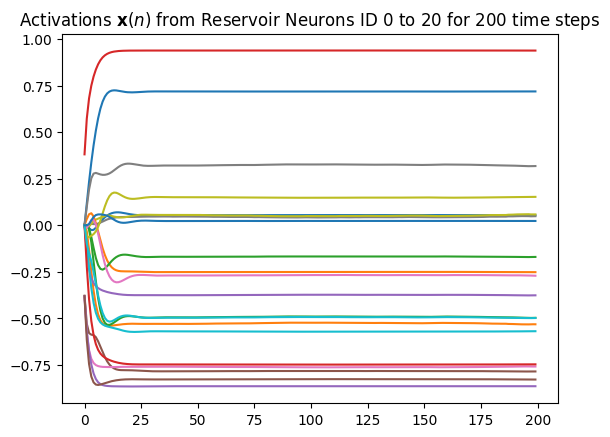

Mean Absolute Error (MAE): 0.0103
Root Mean Squared Error (RMSE): 0.0141
Mean Absolute Percentage Error (MAPE): 1.3707%
R-squared: 0.9844

********************
Errors computed over 608 time steps

Mean Squared error (MSE):	1.9875e-04
Root Mean Squared error (RMSE):	1.4098e-02
Normalized RMSE (based on mean):	1.8846e-02
Normalized RMSE (based on max - min):	2.6743e-02
********************


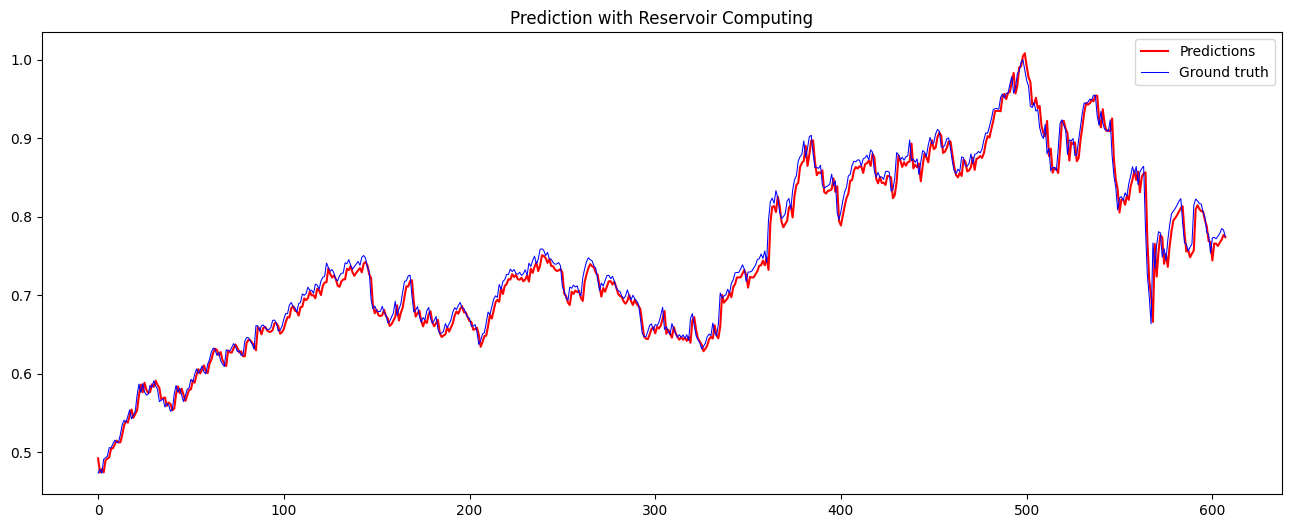

In [238]:
AAPL = train_rc_model(train, trade, 'AAPL', 'close', 1)

Train (3777,)
max: 267.8797912597656 min: 27.639163970947266
mean: 112.5072398469787 std: 64.1520026171303
Test (608,)
max: 329.1125183105469 min: 201.2850341796875
mean: 268.08491445842543 std: 34.50717623260275
(3776, 1)
(3776, 1)
(608, 1)
(608, 1)


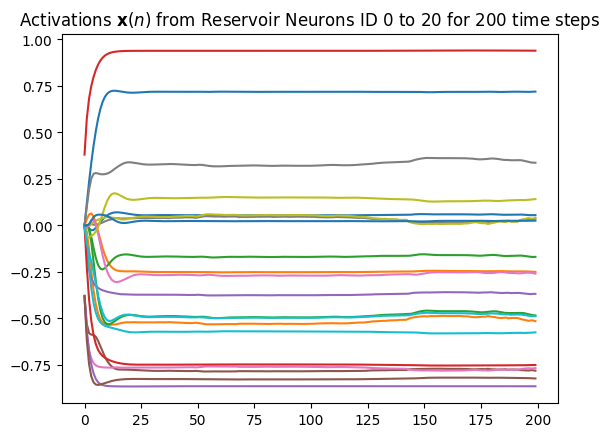

Mean Absolute Error (MAE): 0.0107
Root Mean Squared Error (RMSE): 0.0154
Mean Absolute Percentage Error (MAPE): 1.3185%
R-squared: 0.9819

********************
Errors computed over 608 time steps

Mean Squared error (MSE):	2.3694e-04
Root Mean Squared error (RMSE):	1.5393e-02
Normalized RMSE (based on mean):	1.9300e-02
Normalized RMSE (based on max - min):	3.6303e-02
********************


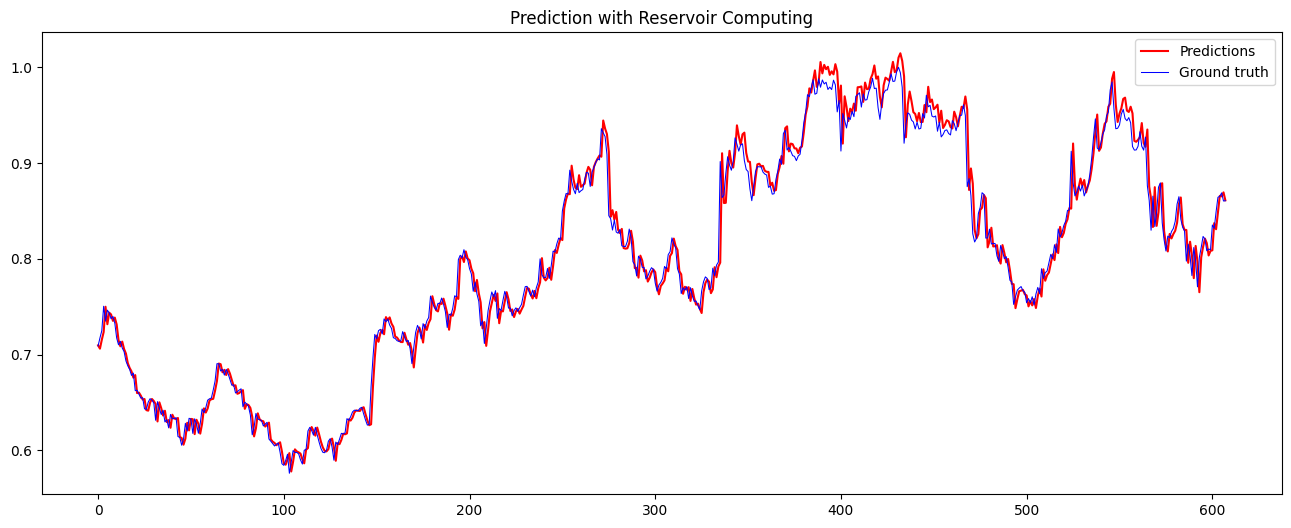

In [241]:
AMGN = train_rc_model(train, trade, 'AMGN', 'close', 1)

In [242]:
ticker_list

['AXP',
 'AMGN',
 'AAPL',
 'BA',
 'CAT',
 'CSCO',
 'CVX',
 'GS',
 'HD',
 'HON',
 'IBM',
 'INTC',
 'JNJ',
 'KO',
 'JPM',
 'MCD',
 'MMM',
 'MRK',
 'MSFT',
 'NKE',
 'PG',
 'TRV',
 'UNH',
 'CRM',
 'VZ',
 'V',
 'WBA',
 'WMT',
 'DIS',
 'DOW']

In [ ]:
for x in ticker_list:
    rc = 

In [54]:
close_df = processed_full.pivot_table(index='date', columns='tic', values='close', aggfunc='mean')
close_df

tic,AAPL,AMGN,AMZN,AXP,BA,CAT,CRM,CSCO,CVX,DIS,...,MMM,MRK,MSFT,NKE,NVDA,PG,TRV,UNH,VZ,WMT
date,,,,,,,,,,,,,,,,,,,,,
2008-01-02,5.855757,32.223801,4.812500,38.898701,63.481628,44.507313,14.962784,17.473333,47.075184,26.682873,...,40.633369,29.839651,25.340914,12.551366,0.756755,43.636864,34.568821,45.000694,16.458725,10.829196
2008-01-03,5.858462,31.594528,4.760500,38.418545,63.745457,44.349770,15.136540,17.611591,47.654415,26.624210,...,40.628460,29.813631,25.448837,12.438309,0.750794,43.636864,35.030960,45.207153,16.534906,10.709128
2008-01-04,5.411257,30.979090,4.439500,37.450657,62.895348,43.183983,14.610312,17.196815,47.019775,26.087875,...,40.166660,29.569176,24.736534,12.245913,0.687751,43.461864,33.928398,44.468651,16.226368,10.556735
2008-01-07,5.338825,31.387081,4.441000,37.618332,60.733353,43.310032,14.337266,17.203402,46.405277,26.113010,...,39.847340,30.125708,24.902021,12.319302,0.616683,43.745499,34.357540,45.167439,16.512039,10.750692
2008-01-08,5.146779,32.037086,4.394000,36.543739,58.564030,42.314396,13.577709,16.742537,45.810902,25.593437,...,39.405205,31.030741,24.067394,12.263764,0.629750,43.860149,33.307808,44.635414,16.154259,10.614463
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-05-30,200.850006,288.179993,205.009995,294.049988,207.320007,348.029999,265.369995,63.040001,136.699997,113.040001,...,148.350006,76.839996,460.359985,60.189999,135.130005,169.889999,275.700012,301.910004,43.959999,98.720001
2025-06-02,201.699997,288.470001,206.649994,295.329987,211.470001,344.670013,261.619995,63.849998,137.839996,112.949997,...,146.399994,76.250000,461.970001,61.570000,137.380005,167.779999,276.339996,304.720001,44.099998,99.769997
2025-06-03,203.270004,289.570007,205.710007,297.390015,213.429993,349.399994,264.470001,64.360001,139.550003,113.599998,...,148.130005,77.139999,462.970001,62.369999,141.220001,166.850006,276.070007,301.220001,43.830002,99.980003


Data dimensions (4385, 28)
max: 665.5557861328125 min: 0.13525764644145966
mean: 93.40426467315618 std: 87.29633418434017


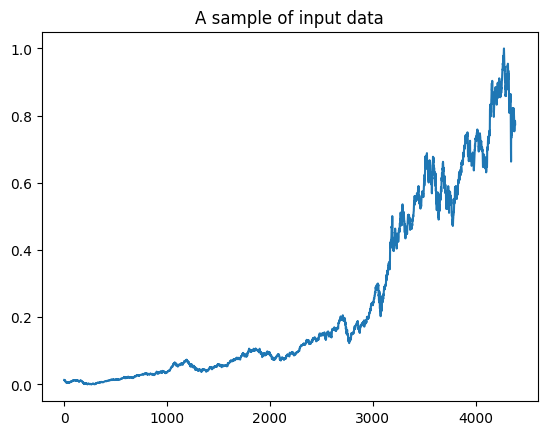

(4200, 1)
(4200, 1)
(100, 1)
(100, 1)


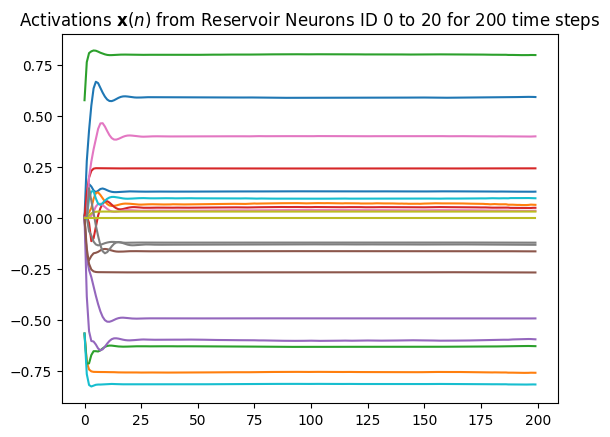

Mean Absolute Error (MAE): 0.0100
Root Mean Squared Error (RMSE): 0.0130
Mean Absolute Percentage Error (MAPE): 1.1191%
R-squared: 0.8886

********************
Errors computed over 100 time steps

Mean Squared error (MSE):	1.6977e-04
Root Mean Squared error (RMSE):	1.3030e-02
Normalized RMSE (based on mean):	1.4454e-02
Normalized RMSE (based on max - min):	7.7885e-02
********************


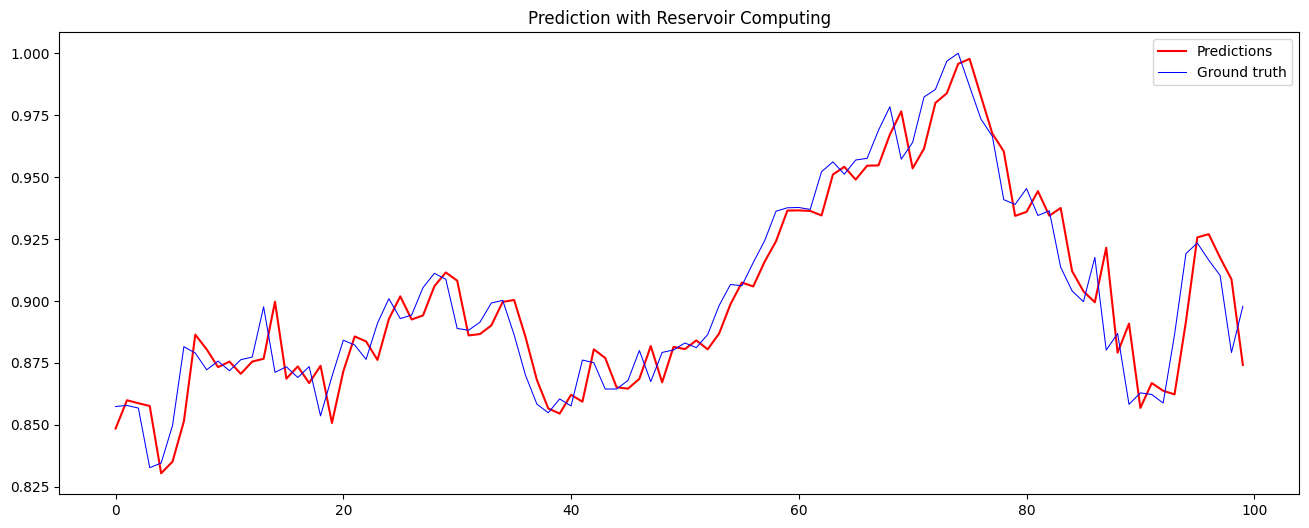

In [81]:
def normalize_data(data):
    return (data - data.min()) / (data.max() - data.min())

df=close_df
Dat = np.array(df)

# Set constants
SEED = 42
VERBOSE = True
units = 10000
horizon = 1

if __name__ == "__main__":
    rpy.set_seed(SEED)
    rpy.verbosity(0)

    if VERBOSE:
        print("Data dimensions", Dat.shape)
        print("max:", Dat.max(), "min:", Dat.min())
        print("mean:", Dat.mean(), "std:", Dat.std())

    data = normalize_data(Dat[:,0])
    
    plt.figure()
    plt.plot(data)
    plt.title("A sample of input data")
    plt.show()

    train_size = 4200
    test_size = 100

    X = data[:train_size].reshape(-1, 1)
    y = data[horizon : train_size + horizon].reshape(-1, 1)
    X_test = data[train_size : train_size + test_size].reshape(-1, 1)
    y_test = data[train_size + horizon : train_size + test_size + horizon].reshape(-1, 1)

    print(X.shape)
    print(y.shape)
    print(X_test.shape)
    print(y_test.shape)

    # Reservoir parameters
    units = 20
    leak_rate = 0.75
    rho = 1.025
    input_scaling = 1.0
    rc_connectivity = 0.15
    input_connectivity = 0.2
    fb_connectivity = 1.1
    regularization_coef = 1e-8
    warmup = 100
    feedback = False

    rng = np.random.default_rng(SEED)
    W = rng.random((units, units)) - 0.5
    input_bias = True  # Set to True or False depending on your choice
    Win = rng.random((units, 1 + int(input_bias))) - 0.5
    Wfb = rng.random((units, 1)) - 0.5

    mask = rng.random((units, units))
    W[mask > rc_connectivity] = 0

    mask = rng.random((units, Win.shape[1]))
    Win[mask > input_connectivity] = 0

    mask = rng.random((units, Wfb.shape[1]))
    Wfb[mask > fb_connectivity] = 0

    Win = Win * input_scaling

    # Calculate the spectral radius
    original_spectral_radius = np.max(np.abs(np.linalg.eigvals(W)))

    # Rescale the matrix to reach the requested spectral radius:
    W = W * (rho / original_spectral_radius)

    # Create a reservoir
    reservoir = Reservoir(
        units,
        lr=leak_rate,
        sr=rho,
        input_bias=input_bias,
        input_scaling=input_scaling,
        rc_connectivity=rc_connectivity,
        input_connectivity=input_connectivity,
        fb_connectivity=fb_connectivity,
    )

    readout = Ridge(ridge=regularization_coef)

    if feedback:
        reservoir = reservoir << readout

    esn = reservoir >> readout

    internal_trained = reservoir.run(X)

    reservoir.reset()

    plt.figure()
    plt.plot(internal_trained[:200, :21])
    plt.title("Activations $\\mathbf{x}(n)$ from Reservoir Neurons ID 0 to 20 for 200 time steps")
    plt.show()

    esn = esn.fit(X, y, warmup=warmup)

    y_pred = esn.run(X_test)

    mae, rmse, mape, mse_score, rmse_score, nmrse_mean, nmrse_maxmin, r2 = calculate_metrics(y_test, y_pred)

    print("Mean Absolute Error (MAE): {:.4f}".format(mae))
    print("Root Mean Squared Error (RMSE): {:.4f}".format(rmse))
    print("Mean Absolute Percentage Error (MAPE): {:.4f}%".format(mape))
    print("R-squared: {:.4f}".format(r2))
    print("\n********************")
    print(f"Errors computed over {test_size} time steps")
    print("\nMean Squared error (MSE):\t%.4e" % mse_score)
    print("Root Mean Squared error (RMSE):\t%.4e" % rmse_score)
    print("Normalized RMSE (based on mean):\t%.4e" % nmrse_mean)
    print("Normalized RMSE (based on max - min):\t%.4e" % nmrse_maxmin)
    print("********************")

    plt.figure(figsize=(16, 6))
    plt.plot(y_pred, color="red", lw=1.5, label="Predictions")
    plt.plot(y_test, color="blue", lw=0.75, label="Ground truth")
    plt.title("Prediction with Reservoir Computing")
    plt.legend()
    plt.show()

end_time = time.time()

In [79]:
len(Dat[:,0])

4385

In [76]:
y

array([[0.00860088, 0.04727728, 0.00695086, ..., 0.06773445, 0.02464554,
        0.01589051],
       [0.00792882, 0.04635239, 0.00646845, ..., 0.06662462, 0.02418187,
        0.01566149],
       [0.00781997, 0.04696552, 0.00647071, ..., 0.06767477, 0.02461118,
        0.01595297],
       ...,
       [0.06301933, 0.22413609, 0.09697738, ..., 0.32783691, 0.05246783,
        0.04596752],
       [0.06273719, 0.22615714, 0.09707206, ..., 0.32809328, 0.05283567,
        0.04609589],
       [0.06222227, 0.22980467, 0.09953141, ..., 0.3283765 , 0.05441936,
        0.0464766 ]])